In [29]:
# ==========================================================
# Imports
# ==========================================================

import os
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr

from sklearn.metrics import mutual_info_score

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "jet"

In [102]:
# ==========================================================
# User Settings
# ==========================================================

# Layer to analyse
LAYER = "d4"

# activation or output
REPRESENTATION = "abs"

# Spatial map resolution
RESOLUTION = 40

# Gaussian smoothing
SIGMA = 1.8

# Place-cell thresholds
SPATIAL_INFO_THRESHOLD = 0.30
SPARSITY_THRESHOLD = 0.12

# Folder containing the pickle file
DATA_FOLDER = "/Users/ais/Desktop/2026_Summer"

# Pickle filename
DATA_FILE = "2D-traj-results.pkl"

In [103]:
# ==========================================================
# Load trajectory data
# ==========================================================

trajectory_path = os.path.join(DATA_FOLDER, DATA_FILE)

with open(trajectory_path, "rb") as f:
    traj_data = pickle.load(f)

print("Keys in trajectory file:\n")

for key in traj_data.keys():
    value = traj_data[key]

    if isinstance(value, np.ndarray):
        print(f"{key:<15} {value.shape}")
    else:
        print(f"{key:<15} {type(value)}")

Keys in trajectory file:

time            (500,)
ground_truth    (50, 500, 2)
prediction      (50, 500, 2)
d1              (50, 500, 100)
z1              (50, 500, 100)
d2              (50, 500, 100)
z2              (50, 500, 100)
d3              (50, 500, 100)
z3              (50, 500, 100)
d4              (50, 500, 100)


In [104]:
# ==========================================================
# Helper Functions
# ==========================================================

def get_representation(layer_data, representation="abs"):
    """
    Extract different representations from complex activations.

    Parameters
    ----------
    layer_data : ndarray
        Shape: (n_traj, n_steps, n_neurons)
        Complex-valued activations.

    representation : str
        "abs"  : Magnitude
        "real" : Real component
        "imag" : Imaginary component
        "phase": Phase angle

    Returns
    -------
    ndarray
        Real-valued array with shape (n_traj, n_steps, n_neurons)
    """

    if representation == "abs":
        return np.abs(layer_data)

    elif representation == "real":
        return np.real(layer_data)

    elif representation == "imag":
        return np.imag(layer_data)

    elif representation == "phase":
        return np.angle(layer_data)

    else:
        raise ValueError(
            f"Unknown representation '{representation}'"
        )

def occupancy_map_2d(
    positions,
    resolution=40,
    sigma=1.5,
):
    occ_counts, xedges, yedges = np.histogram2d(
        positions[:, 0],
        positions[:, 1],
        bins=resolution,
    )

    occ_counts = occ_counts.astype(float)

    occ_smooth = gaussian_filter(
        occ_counts,
        sigma=sigma,
    )

    occ_prob = occ_smooth / (occ_smooth.sum() + 1e-12)

    return occ_counts, occ_smooth, occ_prob, xedges, yedges


def firing_rate_map_2d(
    activations,
    positions,
    neuron,
    occupancy,
    xedges,
    yedges,
):
    """
    Compute firing-rate map for one neuron on one trajectory.
    """

    weighted_sum, _, _ = np.histogram2d(
        positions[:, 0],
        positions[:, 1],
        bins=[xedges, yedges],
        weights=activations[:, neuron],
    )

    firing_map = weighted_sum / (occupancy + 1e-12)

    firing_map = gaussian_filter(
        firing_map,
        sigma=SIGMA,
    )

    return firing_map


def spatial_information(rate_map, occupancy):
    """
    Spatial Information (Skaggs et al.)
    """

    occ = occupancy.astype(float)

    if occ.sum() == 0:
        return 0

    p = occ / occ.sum()

    r = rate_map

    mean_rate = np.sum(p * r)

    if mean_rate <= 0:
        return 0

    valid = (r > 0) & (p > 0)

    info = np.sum(
        p[valid]
        * (r[valid] / mean_rate)
        * np.log2(r[valid] / mean_rate)
    )

    return info


def sparsity(rate_map, occupancy):
    """
    Population sparsity.
    """

    occ = occupancy.astype(float)

    if occ.sum() == 0:
        return np.nan

    p = occ / occ.sum()

    r = rate_map

    numerator = (np.sum(p * r)) ** 2
    denominator = np.sum(p * (r ** 2))

    if denominator == 0:
        return np.nan

    return numerator / denominator

In [105]:
# ==========================================================
# PIPELINE A
# Combine all trajectories
# ==========================================================

positions_all = traj_data["prediction"]

activations_all = get_representation(
    traj_data[LAYER],
    REPRESENTATION
)

print("Original")

print("positions :", positions_all.shape)
print("activations :", activations_all.shape)

positions = positions_all.reshape(-1, 2)
activations = activations_all.reshape(-1, activations_all.shape[-1])

print("\nCombined")

print("positions :", positions.shape)
print("activations :", activations.shape)

Original
positions : (50, 500, 2)
activations : (50, 500, 100)

Combined
positions : (25000, 2)
activations : (25000, 100)


In [106]:
# ==========================================================
# Combined Occupancy Map
# ==========================================================
# ==========================================================
# Combined Occupancy
# ==========================================================

xmin = positions[:, 0].min()
xmax = positions[:, 0].max()

ymin = positions[:, 1].min()
ymax = positions[:, 1].max()

xedges = np.linspace(xmin, xmax, RESOLUTION + 1)
yedges = np.linspace(ymin, ymax, RESOLUTION + 1)

occ_counts, _, _ = np.histogram2d(
    positions[:, 0],
    positions[:, 1],
    bins=[xedges, yedges],
)
occ_counts = occ_counts.astype(float)

occ_smooth = gaussian_filter(
    occ_counts,
    sigma=SIGMA,
)

occ_prob = occ_smooth / (occ_smooth.sum() + 1e-12)

print("Occupancy")

print("Counts :", occ_counts.shape)
print("Smooth :", occ_smooth.shape)
print("Prob   :", occ_prob.shape)

print("Probability sum =", occ_prob.sum())

Occupancy
Counts : (40, 40)
Smooth : (40, 40)
Prob   : (40, 40)
Probability sum = 1.0


In [107]:
# ==========================================================
# Combined Firing Maps
# ==========================================================

num_neurons = activations.shape[1]

combined_firing_maps = np.zeros(
    (
        num_neurons,
        RESOLUTION,
        RESOLUTION,
    )
)

for neuron in range(num_neurons):

    combined_firing_maps[neuron] = firing_rate_map_2d(
        activations,
        positions,
        neuron,
        occ_smooth,
        xedges,
        yedges,
    )

print("Combined firing maps")

print(combined_firing_maps.shape)

Combined firing maps
(100, 40, 40)


In [108]:
# ==========================================================
# Spatial Information
# ==========================================================

spatial_info = np.zeros(num_neurons)

for neuron in range(num_neurons):

    spatial_info[neuron] = spatial_information(
        combined_firing_maps[neuron],
        occ_prob,
    )

print("Spatial Information")

print("Mean :", spatial_info.mean())
print("Max  :", spatial_info.max())
print("Min  :", spatial_info.min())

Spatial Information
Mean : 0.21973424107894185
Max  : 0.48552587781268136
Min  : 0.08439606313079637


In [109]:
# ==========================================================
# Sparsity
# ==========================================================

sparsity_scores = np.zeros(num_neurons)

for neuron in range(num_neurons):

    sparsity_scores[neuron] = sparsity(
        combined_firing_maps[neuron],
        occ_prob,
    )

print("Sparsity")

print("Mean :", sparsity_scores.mean())
print("Max  :", sparsity_scores.max())
print("Min  :", sparsity_scores.min())

Sparsity
Mean : 0.7764413341946462
Max  : 0.8992732975044239
Min  : 0.6066214256730845


In [110]:
# ==========================================================
# Detect Place Cells
# ==========================================================

place_cells = np.where(
    (spatial_info > SPATIAL_INFO_THRESHOLD)
    &
    (sparsity_scores < SPARSITY_THRESHOLD)
)[0]

print("=" * 50)
print(f"Layer : {LAYER}")
print(f"Representation : {REPRESENTATION}")
print("=" * 50)

print()

print(f"Detected place cells : {len(place_cells)} / {num_neurons}")

print()

print("Indices")

print(place_cells)

Layer : d4
Representation : abs

Detected place cells : 0 / 100

Indices
[]


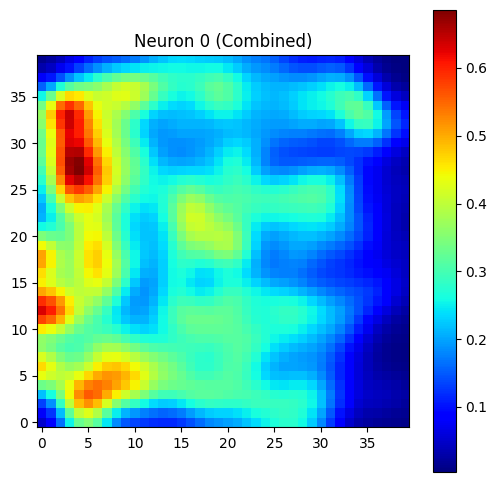

In [111]:
plt.figure(figsize=(6,6))

plt.imshow(
    combined_firing_maps[0].T,
    origin="lower",
    cmap="jet"
)

plt.colorbar()
plt.title("Neuron 0 (Combined)")
plt.show()

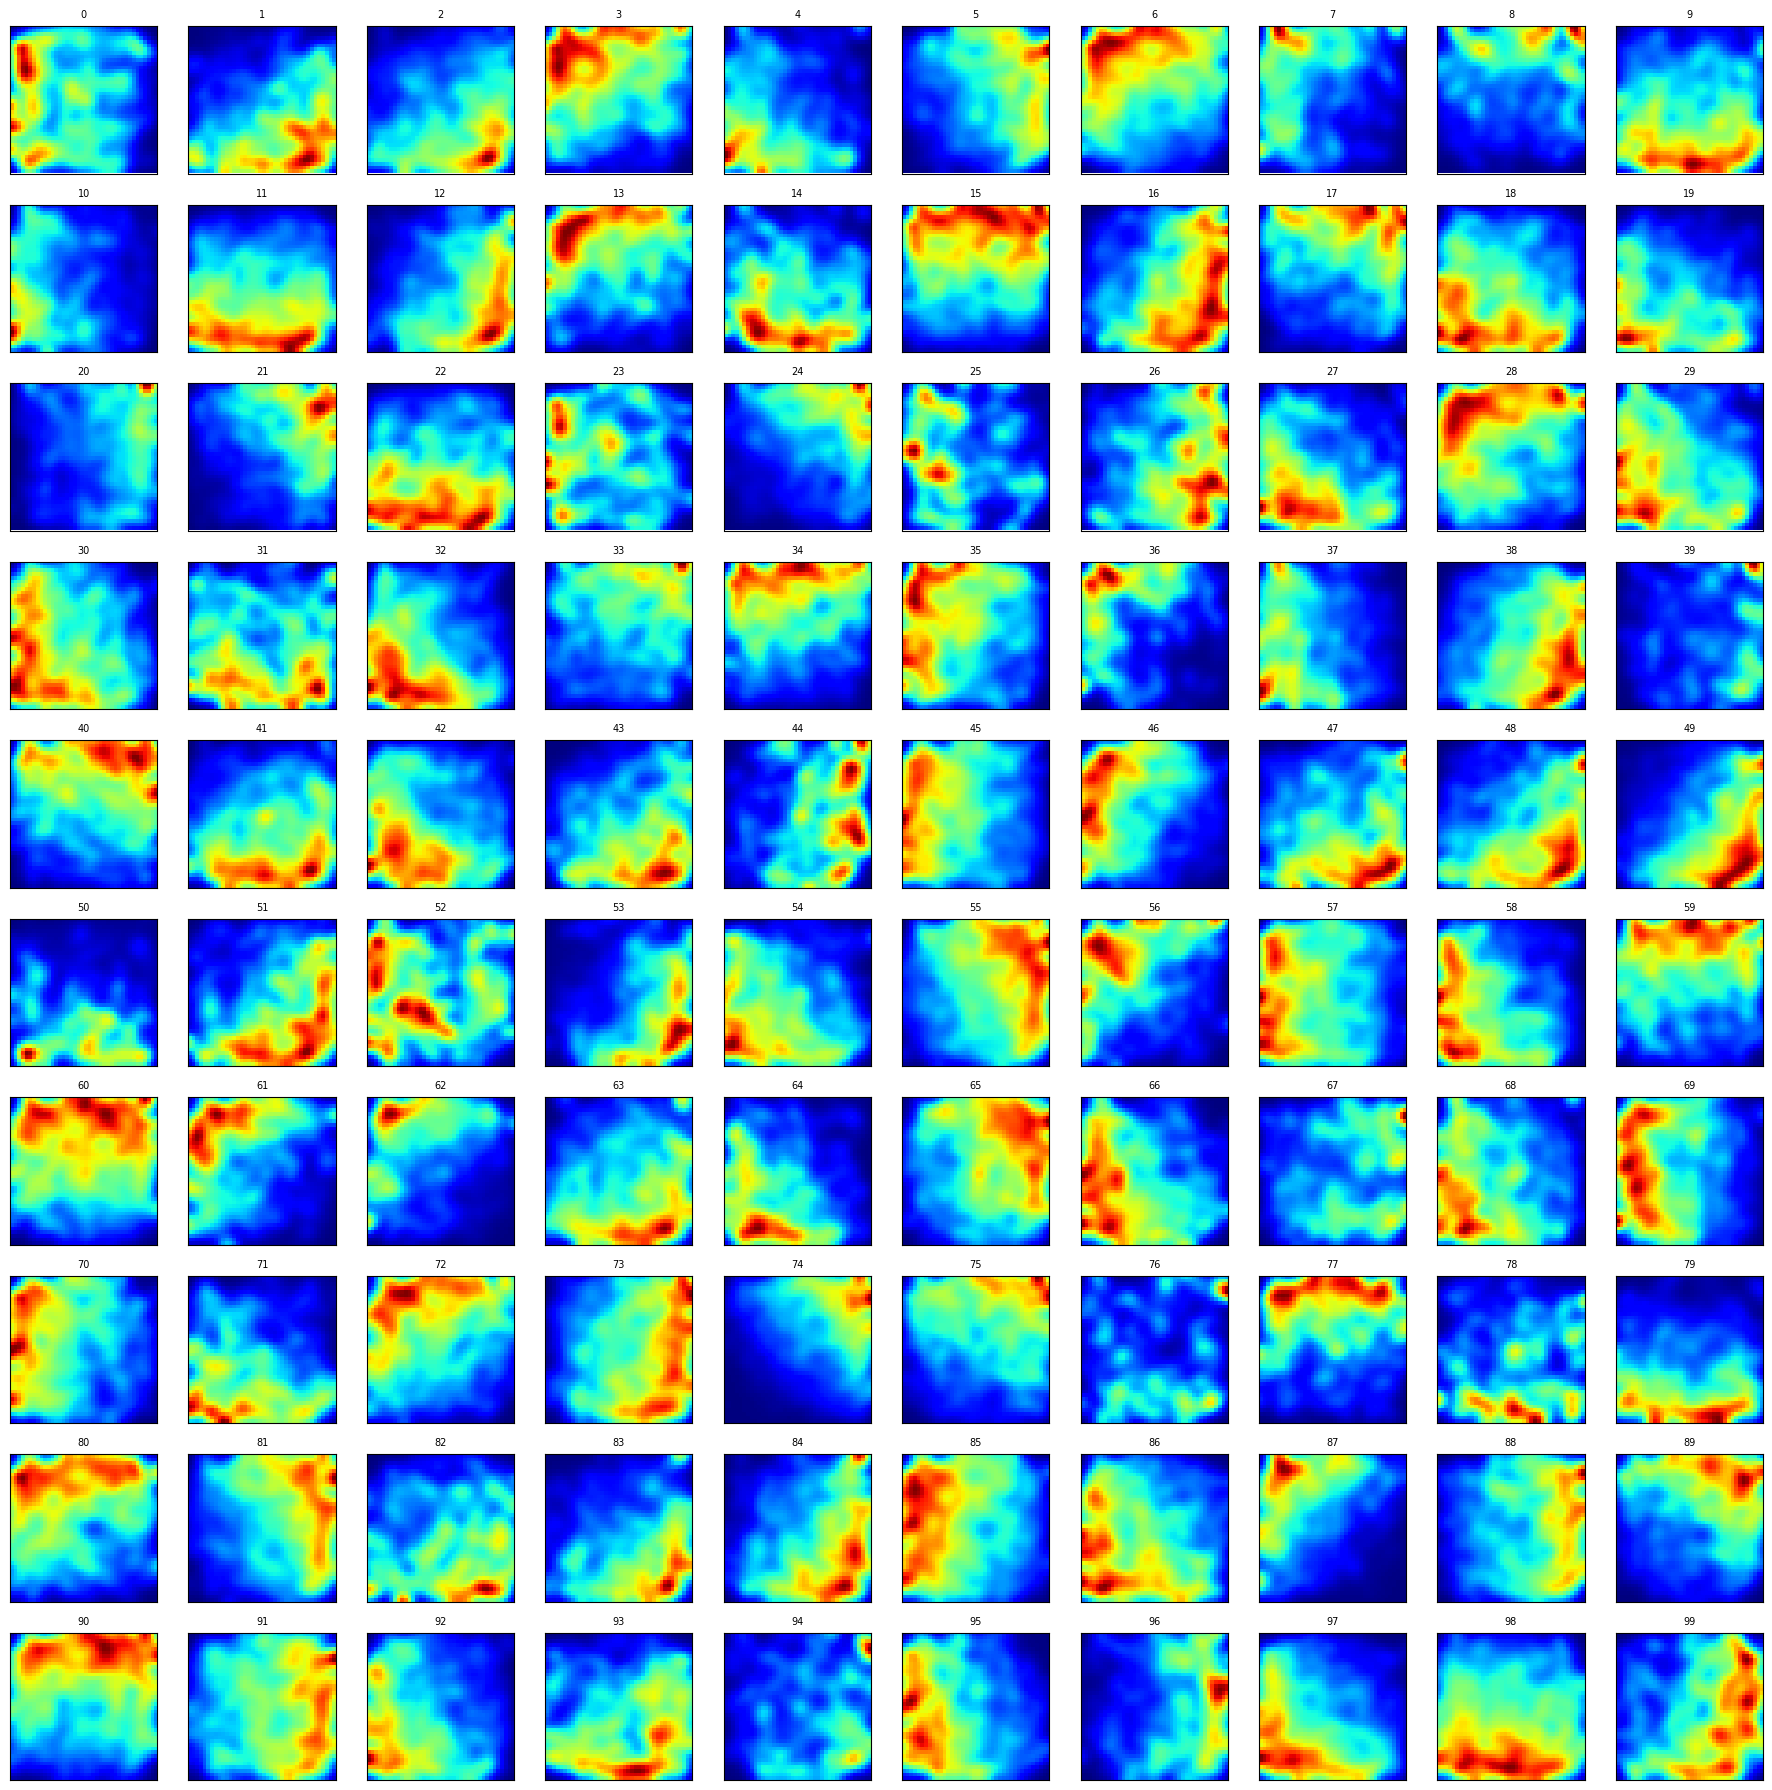

In [112]:
fig, axes = plt.subplots(10, 10, figsize=(18,18))

for neuron, ax in enumerate(axes.flat):
    ax.imshow(
        combined_firing_maps[neuron].T,
        origin="lower",
        cmap="jet"
    )
    ax.set_title(str(neuron), fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()